# Premier contrôleur d'exposition SAC

^GSPC (indice S&P 500) est l'actif tradé. La baseline choisit la direction et le budget de risque.
SAC choisit directement le multiplicateur financier $A_t \in [0, A_{max}]$ : $A_t = 1$ reproduit la baseline, en dessous il l'atténue, au-dessus il l'amplifie. L'exposition finale est $w_t = \mathrm{clip}(A_t\, w^{base}_t,\ \pm w_{max})$.

La récompense est le P&L net moins une pénalité de risque :

$$r_t = 100\,\Big[\underbrace{w_t\, r_{t+1}}_{\text{P\&L de marché}} - \underbrace{c\,|w_t - w_{t-1}|}_{\text{coût de turnover}} - \underbrace{\lambda_{risk}\,(w_t\, r_{t+1})^2}_{\Psi_{t+1}}\Big]$$

In [1]:
import matplotlib.pyplot as plt

from utils import (
    AgentFeatures,
    LongOnly,
    MACDSignal,
    MarketDataLoader,
    SignReturn,
    TrendVolatilityBaseline,
    WalkForwardRunner,
)

## 1. Données en mémoire

In [2]:
# Le chargement precede de deux ans le premier train : vol_regime demande une
# volatilite 21 jours puis sa mediane 252 jours, soit ~273 seances d'echauffement
# perdues au dropna. Sans cette marge, le train du fold 0 serait ampute.
#
# ^GSPC est un indice : aucun dividende, aucun split, donc auto_adjust n'a rien a
# reajuster et l'historique revient identique d'un telechargement a l'autre. C'est
# ce qui rend les resultats reproductibles sans figer la serie sur disque. Un ETF
# comme SPY n'a pas cette propriete : son facteur d'ajustement est recalcule sur la
# fenetre demandee, ce qui decale tout l'historique d'environ 1e-6 en relatif a
# chaque nouveau dividende, assez pour changer les resultats.
#
# end reste fixe pour une autre raison : il gele le nombre de folds. A end=None,
# _splits en produit un de plus des que l'annee civile suivante est complete.
raw_data = MarketDataLoader('^GSPC', '2014-01-01', end='2026-08-25').load()

3178 jours | 2014-01-03 -> 2026-08-24


## 2. Baselines et features de l'agent



In [3]:
# w_max du papier : la meme borne sert a la baseline et au clip applique apres le
# multiplicateur. Une seule source pour les deux, sinon elles divergent en silence.
MAX_EXPOSURE = 2.0
# A_max : a 1.0 SAC ne peut qu'attenuer la baseline. A 2.0 il peut aussi l'amplifier,
# et surtout le milieu de la boite d'action vaut A = 1, donc la baseline elle-meme.
A_MAX = 2.0

baseline = TrendVolatilityBaseline(max_exposure=MAX_EXPOSURE)
agent_features = AgentFeatures()

data = baseline.build(raw_data).join(agent_features.build(raw_data))

# Les trois baselines de la section 4.2 du papier de reference. Elles partagent la
# mise a l'echelle par la volatilite et la borne d'exposition de la baseline du
# projet : seul le signal les distingue, donc un ecart de performance s'attribue
# au signal et non a un budget de risque different.
data['w_long_only'] = LongOnly(max_exposure=MAX_EXPOSURE).exposure(raw_data)
data['w_sign_r'] = SignReturn(max_exposure=MAX_EXPOSURE).exposure(raw_data)
data['w_macd'] = MACDSignal(max_exposure=MAX_EXPOSURE).exposure(raw_data)

# Nom affiche dans les tableaux -> colonne d'exposition. Passe tel quel au runner.
BASELINE_COLUMNS = {
    'Long_only': 'w_long_only',
    'Sign(R)': 'w_sign_r',
    'MACD': 'w_macd',
}

state_columns = [*agent_features.FEATURES, 'signal', 'w_base']
# Le MACD a le plus long echauffement du lot, 63 + 252 seances pour sa double
# normalisation. Il retire une quarantaine de lignes de plus que les features de
# l'agent, toutes anterieures a avril 2015 et donc bien avant le premier train de
# janvier 2016 : les folds et les resultats SAC deja obtenus sont inchanges.
data = data.dropna(subset=[*state_columns, *BASELINE_COLUMNS.values()])

state_variables = [*state_columns, 'previous_exposure']
print(f'Features agent ({len(agent_features.FEATURES)}) : {agent_features.FEATURES}')
print(f'State SAC ({len(state_variables)}) : {state_variables}')
print(f'References ({len(BASELINE_COLUMNS)}) : {list(BASELINE_COLUMNS)}')
data[['price', 'w_base', *BASELINE_COLUMNS.values()]].tail()

Features agent (7) : ['momentum_21', 'momentum_63', 'return_z', 'vol_regime', 'vol_short_long_ratio', 'downside_vol_ratio', 'market_drawdown']
State SAC (10) : ['momentum_21', 'momentum_63', 'return_z', 'vol_regime', 'vol_short_long_ratio', 'downside_vol_ratio', 'market_drawdown', 'signal', 'w_base', 'previous_exposure']
References (3) : ['Long_only', 'Sign(R)', 'MACD']


,price,w_base,w_long_only,w_sign_r,w_macd
Date,,,,,
2026-08-18,7691.759766,0.740813,0.740813,0.740813,0.413300
2026-08-19,7707.979980,0.755171,0.755171,0.755171,0.431274
2026-08-20,7641.160156,0.731963,0.731963,0.731963,0.444060
2026-08-21,7674.370117,0.778446,0.778446,0.778446,0.493580
2026-08-24,7652.859863,0.773089,0.773089,0.773089,0.514811


## 3. Protocole financier walk-forward




In [4]:
SAC_CONFIG = {
    # Buffer plus court que total_timesteps : il oublie enfin les transitions les
    # plus anciennes de la fenetre de train, ce que la non-stationnarite demande.
    # A 50k pour 10k pas, le parametre etait inerte.
    'buffer_size': 20_000,
    'learning_starts': 1_000,
    'gamma': 0.96,
    'policy_kwargs': {'net_arch': [64, 64]},
}

# Poids de Psi_{t+1} = (w_t * r_{t+1})^2 dans la recompense. Arbitrage rendement /
# variance, les deux annualises : sans cout, w* = mu / (2 * LAMBDA_RISK * sigma^2).
# A mu ~ 13 % et sigma ~ 18 %, la valeur 2.0 place w* autour de 1.0, du meme ordre
# que la baseline. LAMBDA_RISK = 0.0 redonne exactement l'ancienne recompense, et
# c'est l'ablation a lancer pour mesurer l'apport du terme de risque.
LAMBDA_RISK = 2.0

experiment = WalkForwardRunner(
    sac_config=SAC_CONFIG,
    state_columns=state_columns,
    first_train_start='2016-01-01',
    train_years=4,
    test_years=1,
    # Longueur des episodes d'entrainement, tires au hasard dans la fenetre de train.
    episode_length=252,
    # True : fenetre glissante de 4 annees civiles.
    # False : fenetre extensible
    rolling_train=True,
    seeds=[42,17,23],
    # 30k pas -> a peu pres 120 episodes de 252 jours par fold.
    total_timesteps=30_000,
    transaction_cost_bps=1.0,
    # Bornes definies en cellule 2 : A_max sur le multiplicateur, w_max reapplique
    # apres lui. max_exposure doit rester celui passe a la baseline.
    a_max=A_MAX,
    max_exposure=MAX_EXPOSURE,
    lambda_risk=LAMBDA_RISK,
    # Adversaires supplementaires, evalues sur le meme bloc OOS et avec le meme
    # cout de turnover que la baseline du projet.
    baseline_columns=BASELINE_COLUMNS,
)

In [5]:
experiment.run(data)
experiment.folds_

Fold 0 | train 2016-01-04 -> 2019-12-31 (1006 j) | test 2020-01-02 -> 2020-12-31


  seed 42 | 118 s | A moyen 0.859 | dispersion 0.762 | sharpe 0.31


  seed 17 | 116 s | A moyen 0.693 | dispersion 0.754 | sharpe 0.45


  seed 23 | 115 s | A moyen 0.628 | dispersion 0.729 | sharpe 0.57


Fold 1 | train 2017-01-03 -> 2020-12-31 (1007 j) | test 2021-01-04 -> 2021-12-31


...

Fold 5 | train 2021-01-04 -> 2024-12-31 (1005 j) | test 2025-01-02 -> 2025-12-31


  seed 42 | 121 s | A moyen 0.819 | dispersion 0.725 | sharpe 1.79


  seed 17 | 121 s | A moyen 0.899 | dispersion 0.717 | sharpe 1.42


  seed 23 | 121 s | A moyen 0.861 | dispersion 0.724 | sharpe 2.37


,train_start,train_end,test_start,test_end
fold,,,,
0,2016-01-04,2019-12-31,2020-01-02,2020-12-31
1,2017-01-03,2020-12-31,2021-01-04,2021-12-31
2,2018-01-02,2021-12-31,2022-01-03,2022-12-30
3,2019-01-02,2022-12-30,2023-01-03,2023-12-29
4,2020-01-02,2023-12-29,2024-01-02,2024-12-31
5,2021-01-04,2024-12-31,2025-01-02,2025-12-31


## 4. Résultats strictement hors échantillon

Les tableaux et la courbe de capital comparent chaque seed SAC, la baseline simple du projet, les trois baselines du papier de référence (`Long_only`, `Sign(R)`, `MACD`) et l'achat simple de l'indice (`Buy_and_hold`).

`Long_only` n'est pas `Buy_and_hold`. La première vise 10 % de volatilité et se redimensionne tous les jours ; la seconde détient une unité de l'indice et ne se rebalance jamais. Leur écart mesure exactement ce qu'apporte le ciblage de volatilité, à vue directionnelle identique.

In [6]:
experiment.metrics_.round(3)

,annual_return,annual_volatility,sharpe_0pct,max_drawdown
SAC_moyen,0.091,0.117,0.810,-0.181
SAC_seed_42,0.073,0.121,0.642,-0.179
SAC_seed_17,0.091,0.128,0.741,-0.196
SAC_seed_23,0.108,0.128,0.864,-0.180
Baseline,0.051,0.112,0.499,-0.185
Long_only,0.085,0.112,0.785,-0.140
Sign(R),0.061,0.112,0.588,-0.159
MACD,0.046,0.075,0.640,-0.143
Buy_and_hold,0.132,0.209,0.700,-0.339


In [7]:
experiment.fold_metrics_['sharpe_0pct'].unstack('strategy').round(2)

strategy,Baseline,Buy_and_hold,Long_only,MACD,SAC_moyen,SAC_seed_17,SAC_seed_23,SAC_seed_42,Sign(R)
fold,,,,,,,,,
0,0.16,0.54,0.65,0.76,0.48,0.45,0.57,0.31,0.28
1,0.94,2.06,1.50,1.79,0.75,0.90,0.37,0.89,1.50
2,-1.27,-0.82,-1.06,-1.61,-1.12,-1.52,-0.76,-0.83,-0.61
3,0.71,1.72,1.46,-0.02,0.99,1.22,0.77,0.69,0.63
4,1.39,1.75,1.39,1.89,1.17,1.06,1.37,0.70,1.39
5,0.98,0.93,0.74,0.75,2.05,1.42,2.37,1.79,0.30


### Tableau de performance du papier de référence

Les neuf indicateurs de la section 4.4 de Zhang, Zohren et Roberts (2019), *Deep Reinforcement Learning for Trading* ([arXiv:1911.10107](https://arxiv.org/abs/1911.10107)), calculés sur les mêmes rendements OOS que les tableaux ci-dessus.

Trois conventions diffèrent de `metrics_` et doivent être lues avant toute comparaison :

- **`E(R)` annualise arithmétiquement**, moyenne × 252, là où `annual_return` compose. Les deux ne coïncident pas et l'écart croît avec la volatilité.
- **`MDD` est une magnitude positive**, quand `max_drawdown` garde son signe négatif. C'est la même quantité, opposée. C'est ce signe qui rend `Calmar` positif pour une stratégie gagnante.
- **`DD` est la semi-déviation**, la racine du moment d'ordre deux de `min(0, r)` sur toutes les séances. Ce n'est *pas* ce que décrit la prose du papier, qui dit « annualised standard deviation of trade returns that are negative ». Son implémentation de référence appelle `empyrical.downside_risk`, qui est la semi-déviation, et le rapport `DD/Vol` publié par sa source le confirme. La lecture littérale reste accessible via `PaperMetrics(downside='negative_std')`.
- **`Calmar` garde un numérateur arithmétique**, ce qui reproduit les tables publiées par la source. `empyrical.calmar_ratio` compose le sien et donne autre chose.

`Sharpe` est identique à `sharpe_0pct` : les deux tableaux partagent maintenant la même implémentation.

Les niveaux ne sont pas comparables à ceux des tables 2 et 3 du papier. Il trade un portefeuille équipondéré de 50 futures à 2 bp de coût, sur 2011-2019 ; on trade ici un seul indice à 1 bp sur 2020-2025. Ce sont les définitions qui sont alignées, pas les conditions d'expérience.


In [8]:
experiment.paper_metrics_.round(3)

,E(R),Std(R),DD,Sharpe,Sortino,MDD,Calmar,% +ve Returns,Ave. P / Ave. L
SAC_moyen,0.094,0.117,0.082,0.810,1.147,0.181,0.522,52.785,1.059
SAC_seed_42,0.078,0.121,0.087,0.642,0.895,0.179,0.434,51.525,1.087
SAC_seed_17,0.095,0.128,0.092,0.741,1.037,0.196,0.486,51.658,1.108
SAC_seed_23,0.110,0.128,0.089,0.864,1.236,0.180,0.614,51.592,1.135
Baseline,0.056,0.112,0.083,0.499,0.671,0.185,0.302,54.045,0.926
Long_only,0.088,0.112,0.083,0.785,1.064,0.140,0.627,54.377,0.959
Sign(R),0.066,0.112,0.084,0.588,0.786,0.159,0.414,55.438,0.889
MACD,0.048,0.075,0.055,0.640,0.880,0.143,0.336,52.984,1.003
Buy_and_hold,0.146,0.209,0.149,0.700,0.985,0.339,0.431,54.377,0.961


In [9]:
# Sortino fold par fold, le seul indicateur du papier absent des tableaux
# precedents qui ne soit pas une reecriture d'une colonne deja affichee.
experiment.paper_fold_metrics_['Sortino'].unstack('strategy').round(2)

strategy,Baseline,Buy_and_hold,Long_only,MACD,SAC_moyen,SAC_seed_17,SAC_seed_23,SAC_seed_42,Sign(R)
fold,,,,,,,,,
0,0.21,0.74,0.83,1.02,0.61,0.58,0.78,0.39,0.36
1,1.28,3.08,2.06,2.67,1.02,1.24,0.49,1.24,2.06
2,-1.65,-1.13,-1.42,-2.04,-1.47,-1.85,-1.03,-1.11,-0.83
3,1.02,2.66,2.17,-0.03,1.52,1.87,1.16,0.99,0.89
4,1.89,2.53,1.89,2.75,1.67,1.49,2.01,1.00,1.89
5,1.34,1.38,0.98,0.97,3.53,2.21,3.84,3.02,0.37


### Comparaison

**SAC bat-il chacun de ses adversaires, en Sharpe OOS, fold par fold ?** La colonne `SAC` est la moyenne des Sharpes des seeds — pas le meilleur seed, et pas non plus `SAC_moyen`, qui est le Sharpe du portefeuille équipondéré sur les seeds et bénéficie de la diversification entre eux.

Le Sharpe est invariant à l'échelle : un multiplicateur constant reproduirait exactement celui de la baseline, au coût de turnover près. `A_dispersion` est donc affichée à côté des comparaisons — une victoire adossée à une dispersion proche de zéro ne dit rien de SAC. Elle ne conditionne rien automatiquement, c'est à la lecture du tableau d'en tenir compte.

Le compte de folds gagnés n'est pas un test statistique. Il faudra un bootstrap par blocs apparié sur la série quotidienne OOS concaténée avant toute affirmation dans le papier.

In [10]:
experiment.summary().round(2)

SAC > Baseline : 4/6 folds
SAC > Long_only : 2/6 folds
SAC > Sign(R) : 3/6 folds
SAC > MACD : 3/6 folds
SAC > Buy_and_hold : 1/6 folds


,SAC,Baseline,Long_only,Sign(R),MACD,Buy_and_hold,A_moyen,A_dispersion,SAC > Baseline,SAC > Long_only,SAC > Sign(R),SAC > MACD,SAC > Buy_and_hold
fold,,,,,,,,,,,,,
0,0.44,0.16,0.65,0.28,0.76,0.54,0.73,0.75,True,False,True,False,False
1,0.72,0.94,1.50,1.50,1.79,2.06,1.36,0.70,False,False,False,False,False
2,-1.04,-1.27,-1.06,-0.61,-1.61,-0.82,0.55,0.70,True,True,False,True,False
3,0.89,0.71,1.46,0.63,-0.02,1.72,0.90,0.75,True,False,True,True,False
4,1.04,1.39,1.39,1.39,1.89,1.75,0.88,0.70,False,False,False,False,False
5,1.86,0.98,0.74,0.30,0.75,0.93,0.86,0.72,True,True,True,True,True


### Décomposition des coûts et saturation

`net = brut − coût` est exact terme à terme, donc cette table isole ce que le turnover retire à chaque stratégie. L'annualisation est **arithmétique** (moyenne × 252) pour que la soustraction reste exacte ; elle ne coïncide donc pas avec `annual_return` de `metrics_`, qui compose.

Le bloc imprimé mesure la saturation de l'action. La récompense étant linéaire en exposition et sans terme de risque, son optimum est sur une borne de $[0, A_{max}]$ : si l'agent y passe l'essentiel de son temps, il fait du tout-ou-rien et non de la modulation.

In [11]:
import pandas as pd

# Memes conventions que l'environnement : rendement du jour suivant, turnover
# contre la position de la veille, position initiale a plat.
d = experiment.decisions_
dates = d.loc[d['seed'] == experiment.seeds[0]].index
annees = len(dates) / 252
r_actif = (data['price'].shift(-1) / data['price'] - 1.0).loc[dates]

expositions = {f'SAC_seed_{s}': d.loc[d['seed'] == s, 'exposure'] for s in experiment.seeds}
expositions['Baseline'] = data.loc[dates, 'w_base']
for nom, colonne in BASELINE_COLUMNS.items():
    expositions[nom] = data.loc[dates, colonne]

lignes = {}
for nom, w in expositions.items():
    turnover = w.diff().abs()
    turnover.iloc[0] = abs(w.iloc[0])
    brut = (w * r_actif).mean() * 252
    cout = experiment.cost_rate * turnover.sum() / annees
    lignes[nom] = {
        'turnover/an': turnover.sum() / annees,
        '|w| moyen': w.abs().mean(),
        'brut/an': brut,
        'cout/an': cout,
        'net/an': brut - cout,
    }

# Saturation : un objectif lineaire en exposition a son optimum sur une borne.
q = d['multiplier'].quantile([0, .05, .25, .5, .75, .95, 1]).round(2)
bornes = ((d['multiplier'] < 0.1) | (d['multiplier'] > experiment.a_max - 0.1)).mean()
print(f'quantiles de A : {q.to_dict()}')
print(f'part du temps colle aux bornes : {100 * bornes:.0f} %')

pd.DataFrame(lignes).T.round(4)

quantiles de A : {0.0: 0.0, 0.05: 0.0, 0.25: 0.09, 0.5: 0.71, 0.75: 1.73, 0.95: 1.99, 1.0: 2.0}
part du temps colle aux bornes : 42 %


,turnover/an,|w| moyen,brut/an,cout/an,net/an
SAC_seed_42,92.5291,0.6336,0.0868,0.0093,0.0775
SAC_seed_17,95.9890,0.6773,0.1046,0.0096,0.0950
SAC_seed_23,97.5797,0.6902,0.1202,0.0098,0.1104
Baseline,16.6124,0.7318,0.0576,0.0017,0.0559
Long_only,7.5647,0.7318,0.0887,0.0008,0.0879
Sign(R),9.3525,0.7318,0.0669,0.0009,0.0659
MACD,7.0868,0.4375,0.0488,0.0007,0.0481


## 5. Graphiques finaux

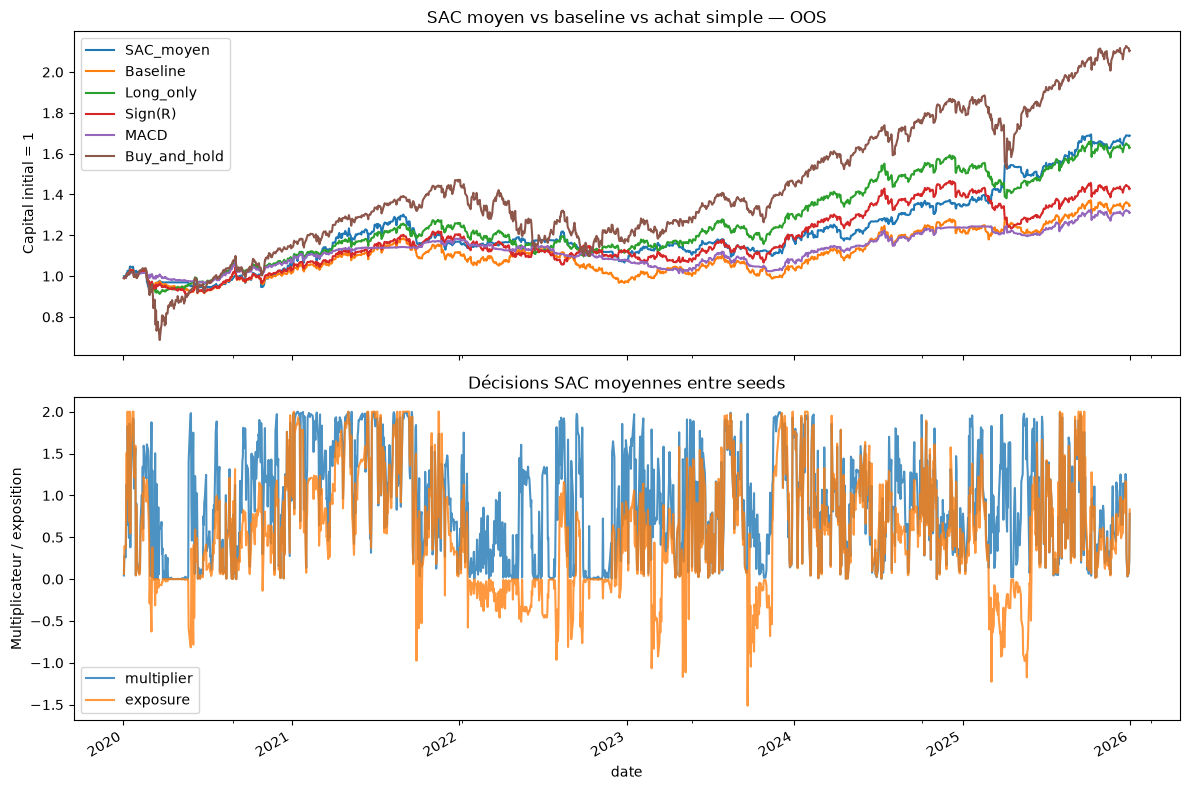

In [12]:
returns = experiment.daily_returns_
# SAC_moyen est calcule dans le runner, donc la courbe tracee ici a bien une ligne
# correspondante dans metrics_ et fold_metrics_. Ce n'est pas la colonne SAC de
# summary() : celle-la moyenne les Sharpes, celle-ci est le Sharpe du portefeuille
# equipondere sur les seeds, qui profite de la diversification entre eux.
comparison = returns[['SAC_moyen', 'Baseline', *BASELINE_COLUMNS, 'Buy_and_hold']]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
(1 + comparison).cumprod().plot(
    ax=axes[0], title='SAC moyen vs baseline vs achat simple — OOS'
)
axes[0].set_ylabel('Capital initial = 1')
experiment.mean_decisions()[['multiplier', 'exposure']].plot(
    ax=axes[1], alpha=0.8, title='Décisions SAC moyennes entre seeds'
)
axes[1].set_ylabel('Multiplicateur / exposition')
plt.tight_layout()
plt.show()

## Points méthodologiques encore ouverts

- **Horizon :** le modèle est désormais continu et actualisé avec $\gamma=0.96$. Le choix de ce discount, soit une masse effective de 25 séances, doit être testé en robustesse (par exemple 0.95, 0.96, 0.97 et 0.99).
- **Instrument :** ^GSPC est un indice *de prix*, non traçable directement et hors dividendes. Le benchmark `Buy_and_hold` est donc sous-estimé d'environ 1,8 %/an — le rendement du dividende du S&P 500 — face à une position réellement détenue en ETF. SAC et la baseline sont mesurés sur la même série, donc leur comparaison mutuelle reste valide, mais l'écart affiché contre `Buy_and_hold` est flatteur et ne doit pas être repris tel quel. Le papier vise par ailleurs les futures S&P 500 : les résultats ne seront pas directement interchangeables.
- **Calibration de $\lambda_{risk}$ :** la valeur 2.0 vient de $w^\star = \mu/(2\lambda_{risk}\sigma^2)$ avec un $\mu$ estimé *ex post* sur l'indice. C'est un choix, pas une mesure. Il faut l'ablation $\lambda_{risk}=0$ et un balayage (0, 1, 2, 4) avant toute affirmation dans le papier.
- **Nombre de seeds :** avec 3 seeds la dispersion entre eux est du même ordre que l'écart mesuré à la baseline. Le comptage de folds gagnés n'a pas la puissance de trancher ; il en faut une quinzaine.
- **Sensibilité aux coûts :** SAC tourne environ 6 fois plus que la baseline. Son avantage en rendement net s'annule vers 4 bp de coût aller-retour, contre 1 bp retenu ici. À reporter comme une sensibilité, pas comme un chiffre unique.
- **Forme de $\Psi$ :** la pénalité est symétrique, elle taxe autant les fortes hausses que les fortes baisses. Une semi-variance $\big(\min(0, w_t r_{t+1})\big)^2$ ne pénaliserait que la baisse et serait plus proche de l'aversion réelle — à comparer.
- **P&L de marché plutôt que net :** $\Psi$ porte sur $w_t r_{t+1}$ et non sur le rendement après coûts, pour que le coût de turnover — déterministe une fois l'action choisie — n'entre pas au carré dans la pénalité.